# Үй жұмысы: Palmer Penguins деректер жинағына EDA және Feature Engineering

**Тақырыбы:** Деректерді зерттеу, тазарту, визуализациялау және модельдеуге дайындау.

**Мақсаты:**
Студент осы жұмысты орындау арқылы Машиналық оқыту жобасының толық циклін қамтитын келесі дағдыларды меңгеруі керек:

1.  **Деректерді тазарту:** Бос мәндермен (Missing Values) және дубликаттармен жұмыс.
2.  **Ауытқуларды өңдеу:** Boxplot және IQR әдісі арқылы outliers-ті анықтау.
3.  **Визуализация:** Matplotlib және Seaborn көмегімен деректердің таралуын және корреляциясын зерттеу.
4.  **Feature Engineering:** Бар деректерден жаңа пайдалы белгілерді жасау.
5.  **Кодтау (Encoding):** Санаттық айнымалыларды (`sex`, `island`, `species`) сандық форматқа ауыстыру.
6.  **Шкалалау (Scaling):** Сандық деректерді бір масштабқа келтіру.

**Дереккөз:** `seaborn` кітапханасындағы кіріктірілген "penguins" деректер жинағы.


## 1\. Кітапханаларды және деректерді жүктеу

Алдымен қажетті кітапханаларды импорттап, деректер жинағын жүктейміз.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder

# Визуализация параметрлерін орнату
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Деректер жинағын жүктеу
df = sns.load_dataset('penguins')

# Алғашқы 5 жолды және деректердің өлшемін шығару
print(f"Деректер өлшемі: {df.shape}")
df.head()

Деректер өлшемі: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


-----

## 2\. Деректерді шолу және Тазарту (Data Cleaning)

Деректерді талдамас бұрын, олардың сапасын тексеріп, бос мәндерден тазартуымыз керек.

**Тапсырма:**

1.  `info()` әдісін қолданып, деректер типін тексеріңіз.
2.  Әр бағанда қанша бос мән (NaN) бар екенін анықтаңыз.
3.  **Стратегия:**
      * Сандық бағандардағы (`bill_length_mm`, `body_mass_g` т.б.) бос мәндерді **медианамен** толтырыңыз.
      * Санаттық бағандардағы (`sex`) бос мәндерді ең жиі кездесетін мәнмен (**mode**) толтырыңыз.

<!-- end list -->

In [3]:
# 1. Деректер туралы ақпарат (info)
# TODO: Кодыңызды осында жазыңыз
print(df.info())

# 2. Бос мәндер санын тексеру
# TODO: Кодыңызды осында жазыңыз
print(df.isnull().sum())

# 3. Бос мәндерді толтыру
# Сандық бағандар үшін (цикл немесе жеке-жеке fillna қолданыңыз)
# TODO: Кодыңызды осында жазыңыз
df['bill_length_mm'].fillna(df['bill_length_mm'].median(), inplace=True)
df['body_mass_g'].fillna(df['body_mass_g'].median(), inplace=True)

# 'sex' бағаны үшін (mode қолданыңыз)
# TODO: Кодыңызды осында жазыңыз
df['sex'].fillna(df['sex'].mode()[0], inplace=True)

# Тексеру: Бос мәндер қалмағанына көз жеткізіңіз
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     344 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        344 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None
species               0
island                0
bill_length_mm        0
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           0
sex                  11
dtype: int64
species              0
island               0
bill_length_mm       0
bill_depth_mm        2
flipper_length_mm    2
body_mass_g          0
sex                  0
dtype: int64


/tmp/ipykernel_974/4027697006.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bill_length_mm'].fillna(df['bill_length_mm'].median(), inplace=True)
/tmp/ipykernel_974/4027697006.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

-----

## 3\. Ауытқуларды анықтау және өңдеу (Outlier Handling)

Кейде деректерде қате енгізілген немесе тым ерекше мәндер болады. Біз оларды IQR (Interquartile Range) әдісімен тазалаймыз.

**Тапсырма:**

1.  `flipper_length_mm` (қанат ұзындығы) бағаны үшін **Boxplot** сызыңыз.
2.  Осы баған үшін **IQR** есептеңіз (Q3 - Q1).
3.  Төменгі (lower bound) және жоғарғы (upper bound) шекті анықтаңыз.
4.  Осы шектен шығатын мәндерді алып тастаңыз (сүзгілеу).

<!-- end list -->

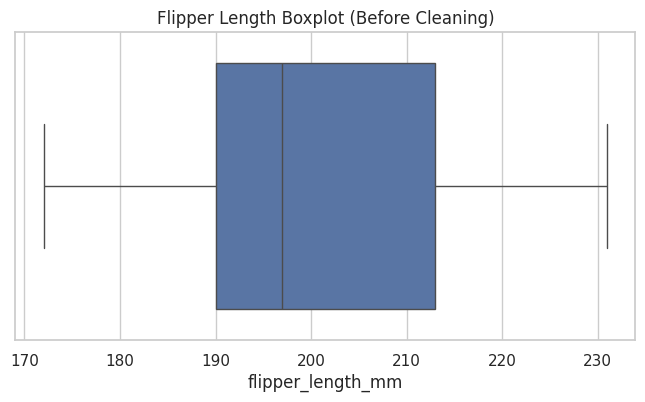

Lower Bound: 155.5
Upper Bound: 247.5
Тазартылғаннан кейінгі деректер өлшемі: (342, 7)


In [6]:
# 1. Boxplot салу
plt.figure(figsize=(8, 4))
# TODO: Seaborn boxplot функциясын қолданыңыз
sns.boxplot(x=df['flipper_length_mm'])
plt.title('Flipper Length Boxplot (Before Cleaning)')
plt.show()

# 2. IQR және шектік мәндерді есептеу
Q1 = df['flipper_length_mm'].quantile(0.25)
Q3 = df['flipper_length_mm'].quantile(0.75)
IQR = Q3 - Q1

# TODO: Q1 және Q3 есептеңіз
# TODO: IQR есептеңіз
# TODO: lower_bound және upper_bound есептеңіз
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f'Lower Bound: {lower_bound}')
print(f'Upper Bound: {upper_bound}')

# 3. Ауытқуларды алып тастау
# TODO: df айнымалысын жаңартып, тек шектік мәндер арасындағы деректерді қалдырыңыз
dfcl = df[(df['flipper_length_mm'] >= lower_bound) & (df['flipper_length_mm'] <= upper_bound)]

print(f"Тазартылғаннан кейінгі деректер өлшемі: {dfcl.shape}")

-----

## 4\. Визуализация (EDA)

Енді таза деректермен жұмыс істейміз. Графиктер арқылы заңдылықтарды іздеңіз.

**Тапсырма:**

1.  **Гистограмма:** `body_mass_g` (салмақ) таралуын көрсетіңіз.
2.  **Нүктелік диаграмма (Scatter Plot):** `bill_length_mm` (тұмсық ұзындығы) мен `bill_depth_mm` (тұмсық тереңдігі) арасындағы байланысты көрсетіңіз. Түрлерді (`species`) түс (`hue`) арқылы ажыратыңыз.
3.  **Жылу картасы (Heatmap):** Барлық сандық айнымалылар арасындағы корреляция матрицасын құрыңыз және визуализациялаңыз.

<!-- end list -->

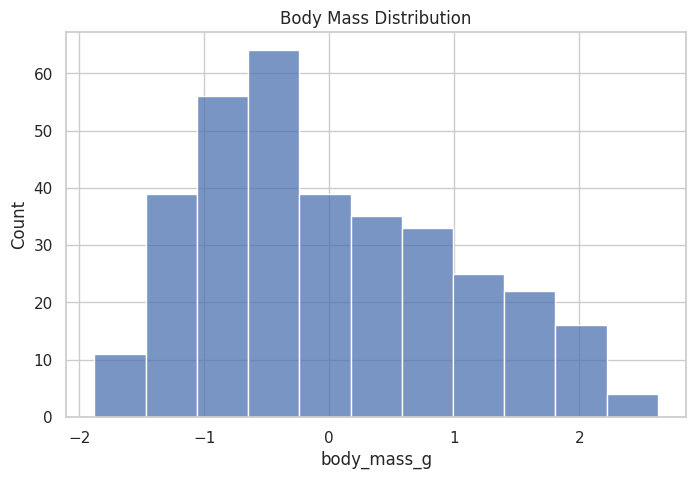

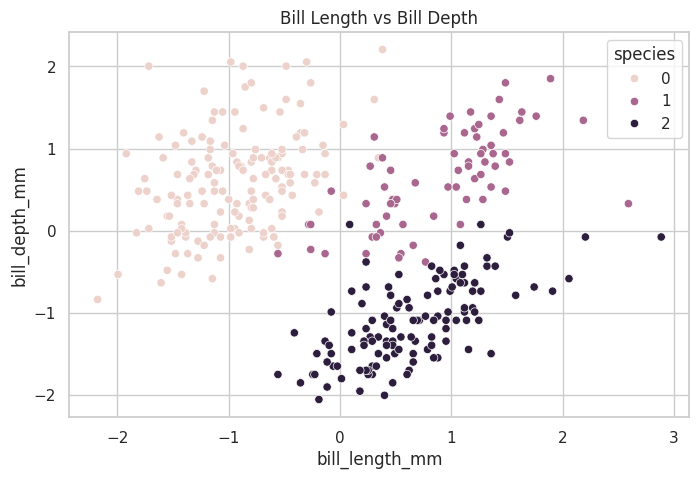

ValueError: could not convert string to float: 'Torgersen'

<Figure size 800x600 with 0 Axes>

In [20]:
# 1. Салмақтың таралуы (Histogram)
plt.figure(figsize=(8, 5))
# TODO: sns.histplot қолданыңыз
sns.histplot(df['body_mass_g'])
plt.title('Body Mass Distribution')
plt.show()

# 2. Scatterplot: Тұмсық ұзындығы vs Тереңдігі
plt.figure(figsize=(8, 5))
# TODO: sns.scatterplot қолданыңыз (hue='species')
sns.scatterplot(x=df['bill_length_mm'], y=df['bill_depth_mm'], hue=df['species'])
plt.title('Bill Length vs Bill Depth')
plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(8, 6))
# TODO: Тек сандық бағандарды таңдап, correlation matrix жасаңыз
cor = df.corr()
sns.heatmap(cor, annot=True, cmap='coolwarm')
# TODO: sns.heatmap арқылы салыңыз
plt.title('Correlation Heatmap')
plt.show()

-----

## 5\. Feature Engineering

Модель жақсы жұмыс істеуі үшін кейде жаңа белгілер (features) ойлап табу керек.

**Тапсырма:**

  * `bill_ratio` атты жаңа баған қосыңыз. Ол тұмсық ұзындығының тереңдігіне қатынасын (`bill_length_mm / bill_depth_mm`) білдіреді.

<!-- end list -->

In [8]:
# Жаңа feature жасау
# TODO: df['bill_ratio'] = ...
df['bill_ratio'] = df['bill_length_mm'] / df['bill_depth_mm']
# Алғашқы 5 жолды тексеру
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,bill_ratio
0,Adelie,Torgersen,39.10,18.7,181.0,3750.0,Male,2.090909
1,Adelie,Torgersen,39.50,17.4,186.0,3800.0,Female,2.270115
2,Adelie,Torgersen,40.30,18.0,195.0,3250.0,Female,2.238889
3,Adelie,Torgersen,44.45,NaN,NaN,4050.0,Male,NaN
4,Adelie,Torgersen,36.70,19.3,193.0,3450.0,Female,1.901554


-----

## 6\. Санаттық белгілерді кодтау (Encoding)

Компьютер сөздерді түсінбейді, сондықтан `island`, `sex`, `species` сияқты сөздік бағандарды сандарға айналдырамыз.

**Тапсырма:**

1.  `species` (біз болжайтын нысана) үшін **Label Encoding** қолданыңыз (0, 1, 2 қылып өзгертеді).
2.  `island` және `sex` үшін **One-Hot Encoding** (`pd.get_dummies`) қолданыңыз. `drop_first=True` параметрін ұмытпаңыз.

<!-- end list -->

In [10]:
# 1. Label Encoding (species)
le = LabelEncoder()
# TODO: df['species'] бағанын трансформациялаңыз
df['species'] = le.fit_transform(df['species'])
# 2. One-Hot Encoding (island, sex)
# TODO: pd.get_dummies қолданып, нәтижені df_encoded айнымалысына сақтаңыз
df_encoded= pd.get_dummies(df, columns=['island', 'sex'], drop_first=True)
# Нәтижені көру
# df_encoded.head()
df_encoded.head()

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,bill_ratio,island_Dream,island_Torgersen,sex_Male
0,0,-0.887622,0.785449,-1.418347,-0.564625,-1.036429,False,True,True
1,0,-0.814037,0.126188,-1.062250,-0.502010,-0.675598,False,True,False
2,0,-0.666866,0.430462,-0.421277,-1.190773,-0.738471,False,True,False
3,0,0.096581,NaN,NaN,-0.188936,NaN,False,True,True
4,0,-1.329133,1.089724,-0.563715,-0.940314,-1.417695,False,True,False


-----

## 7\. Шкалалау (Scaling)

Соңғы қадам – сандық деректерді бір өлшемге келтіру. Мысалы, салмақ 5000 грамм болса, тұмсық ұзындығы 50 мм. Бұл айырмашылық модельге кедергі келтіруі мүмкін.

**Тапсырма:**

  * `StandardScaler` көмегімен барлық сандық белгілерді (`bill_length_mm`, `body_mass_g`, `bill_ratio` т.б.) шкалалаңыз.

<!-- end list -->

flipper_length_mm мен body_mass_g арасындағы корреляция: 0.8712017673060114
flipper_length_mm мен body_mass_g арасындағы корреляция: 0.8712017673060114


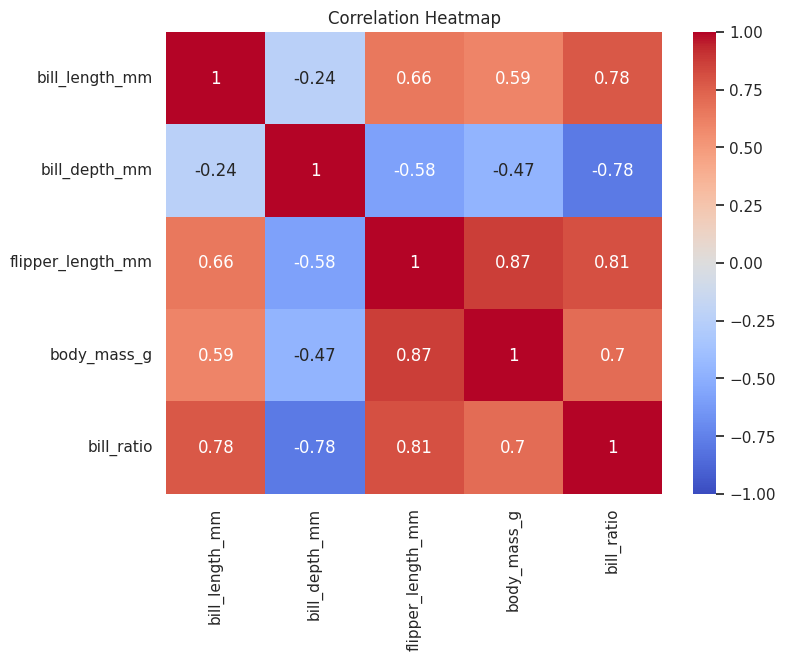

In [14]:
scaler = StandardScaler()

# Шкалаланатын бағандар тізімі
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'bill_ratio']

# Шкалалауды жүзеге асыру
# TODO: fit_transform қолданыңыз және df_encoded ішіндегі бағандарды жаңартыңыз
df[num_cols] = scaler.fit_transform(df[num_cols])
# Қорытынды нәтижені тексеру
# df_encoded.head()
df.head()
correlation = df['flipper_length_mm'].corr(df['body_mass_g'])
print(f"flipper_length_mm мен body_mass_g арасындағы корреляция: {correlation}")
# Шкалалауды орындап, нәтижені қайтадан DataFrame-ге сақтау
df_scaled = pd.DataFrame(scaler.fit_transform(df[num_cols]), columns=num_cols)

# flipper_length_mm мен body_mass_g арасындағы корреляцияны есептеу
correlation = df_scaled['flipper_length_mm'].corr(df_scaled['body_mass_g'])
print(f"flipper_length_mm мен body_mass_g арасындағы корреляция: {correlation}")

# Корреляция матрицасын жасау
corr_matrix = df_scaled.corr()

# Heatmap салу
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

-----

## Қорытынды

**Талдау нәтижесі бойынша қысқаша жауап жазыңыз:**

1.  `body_mass_g` (салмақ) пен `flipper_length_mm` (қанат ұзындығы) арасында қандай корреляция бар (оң ма, теріс пе, күшті ме)?

2.  Heatmap-қа қарап айтыңызшы.

body_mass_g пен flipper_length_mm арасындағы корреляция оң және күшті (0.87)